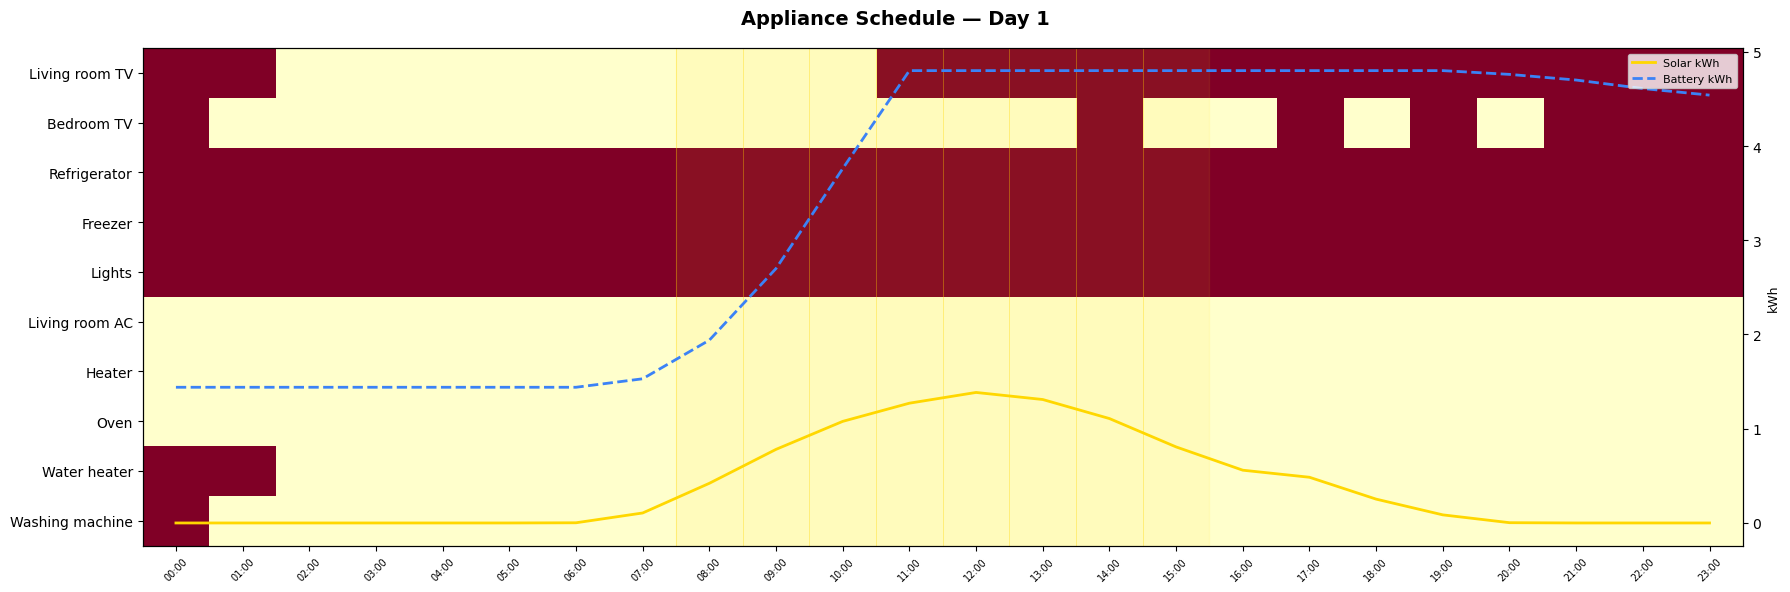

Saved day_1_schedule.png


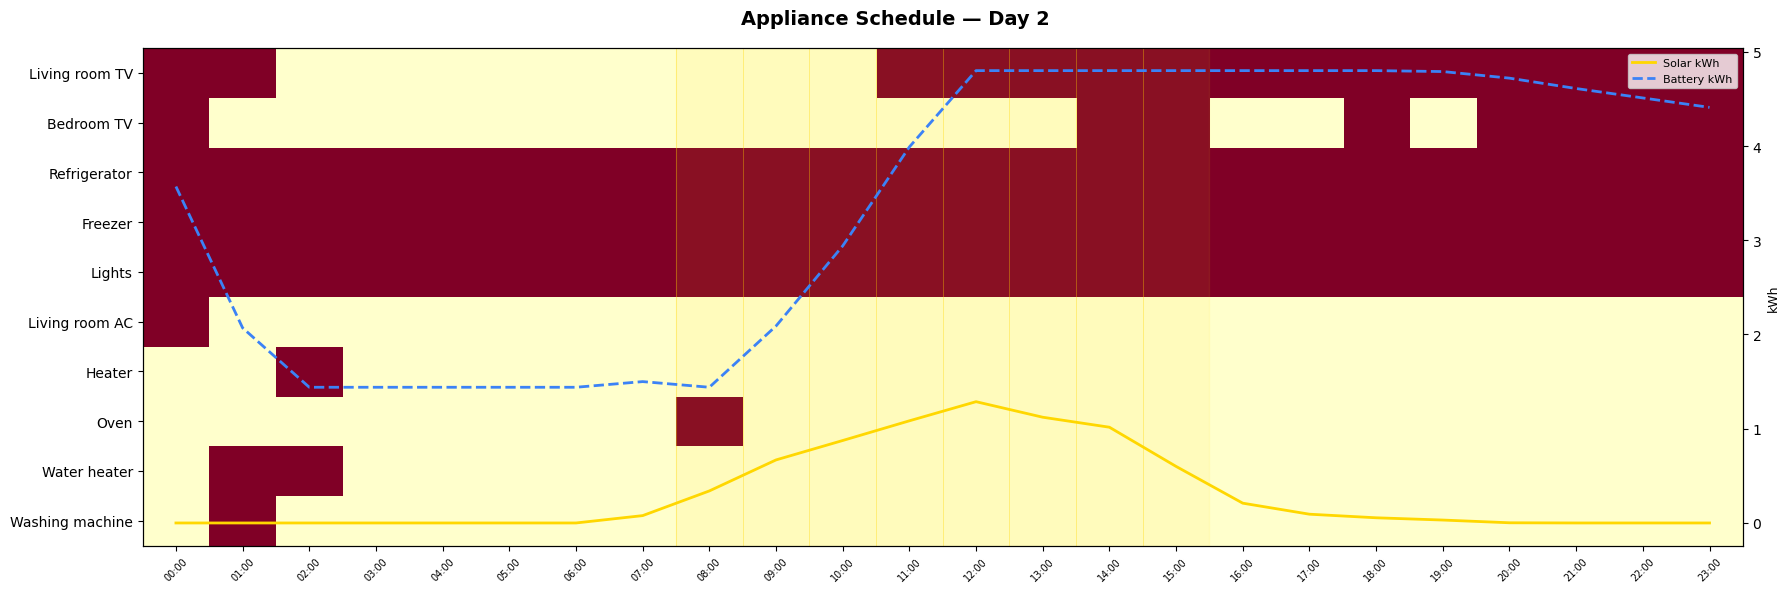

Saved day_2_schedule.png


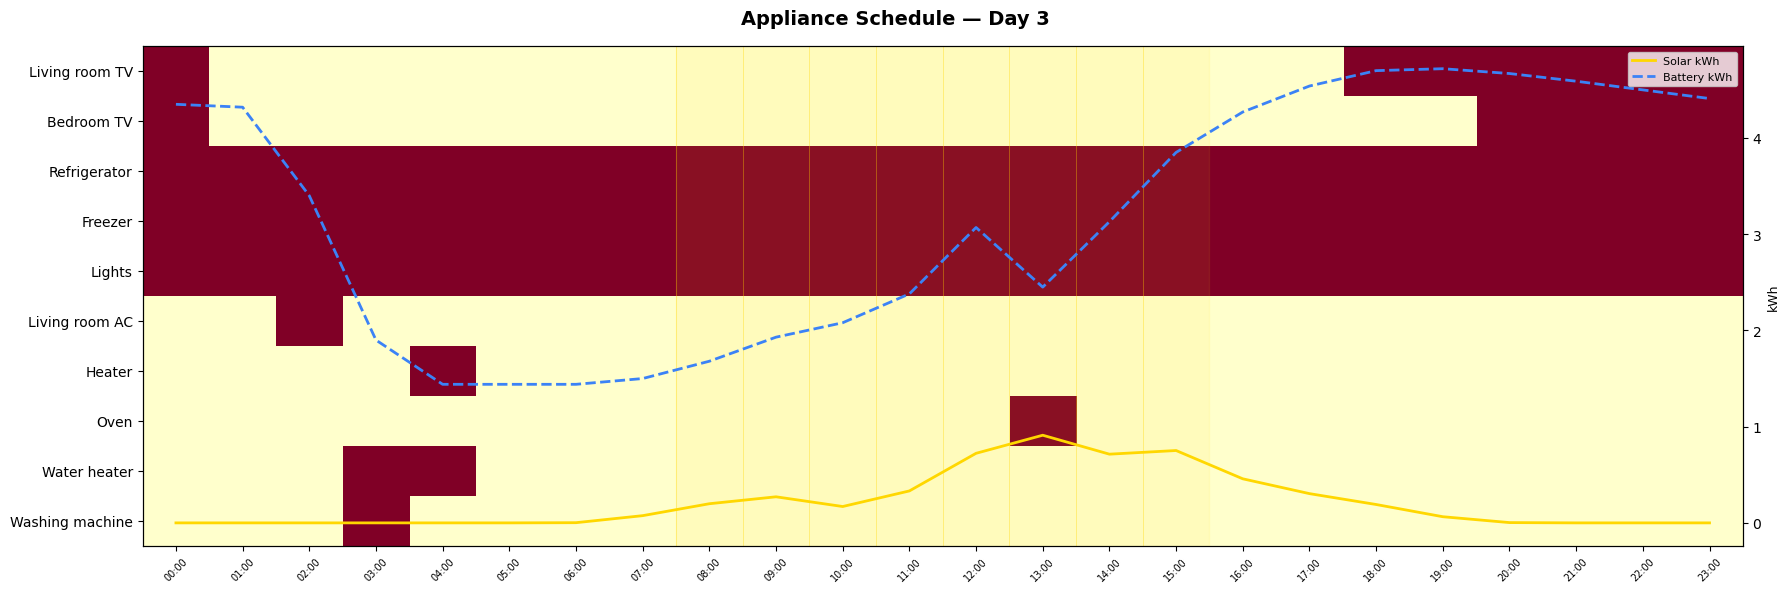

Saved day_3_schedule.png


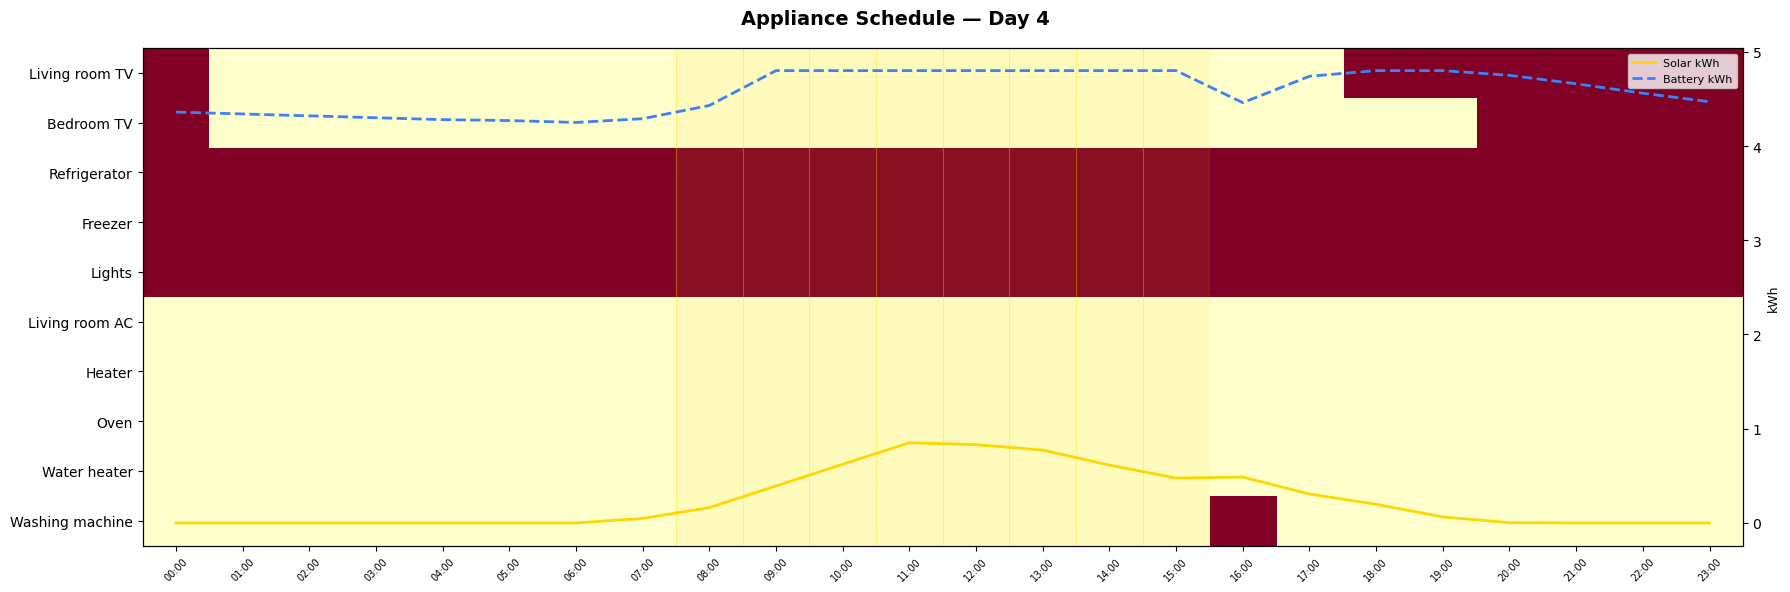

Saved day_4_schedule.png


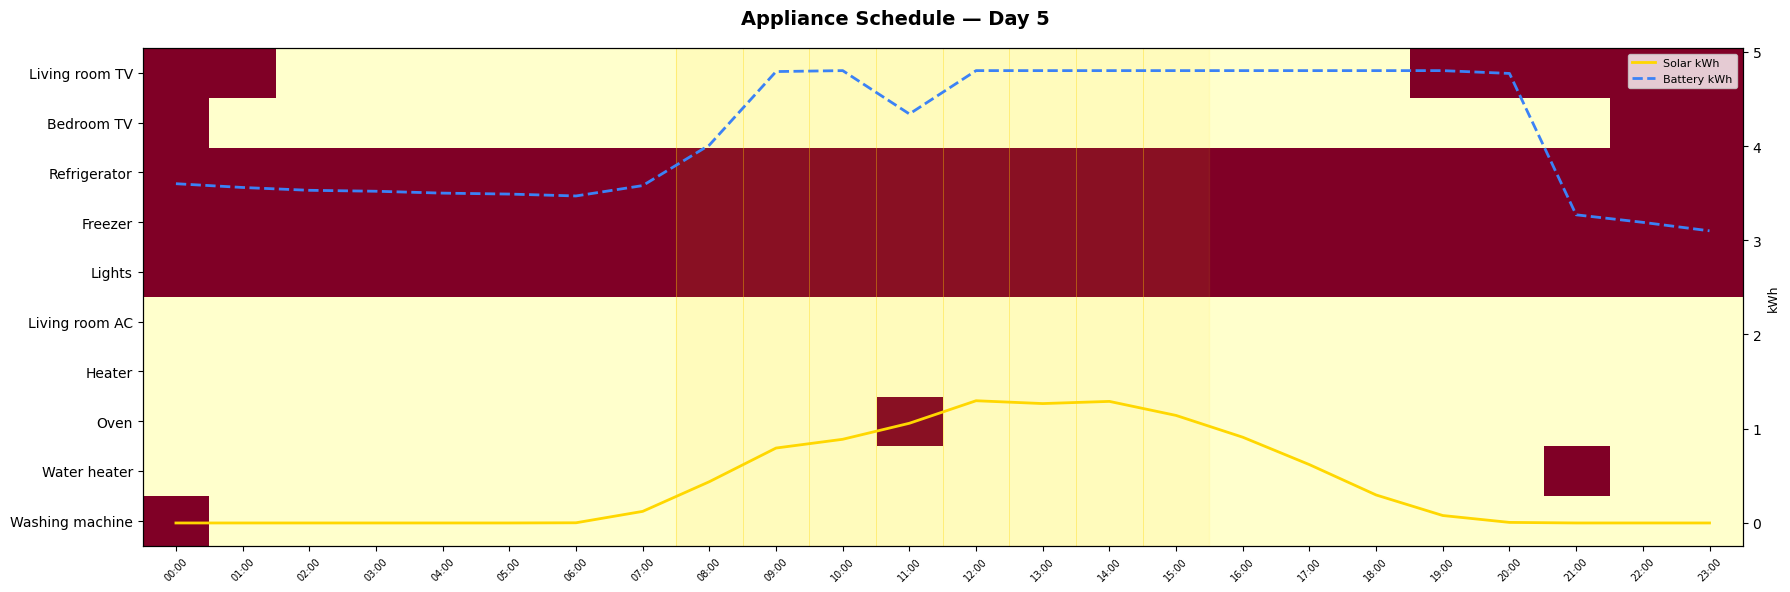

Saved day_5_schedule.png


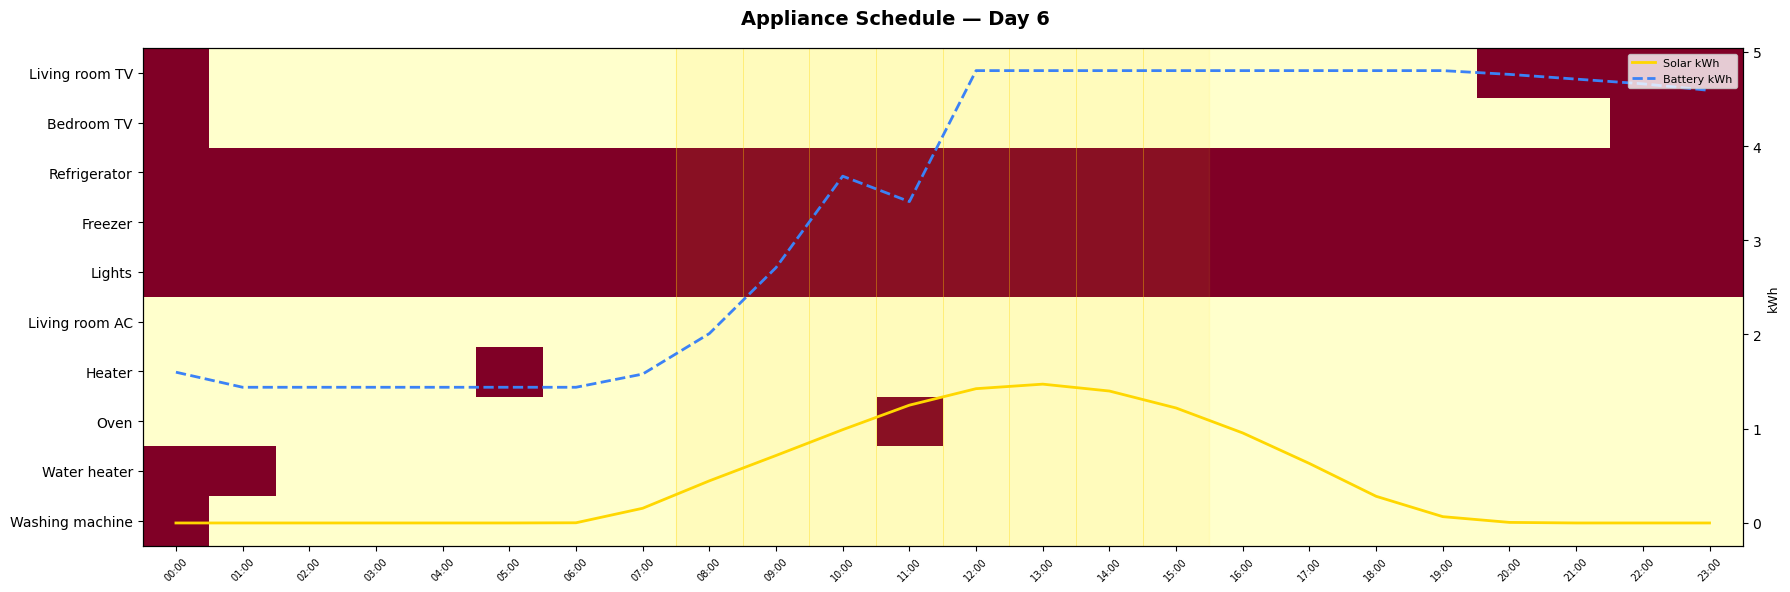

Saved day_6_schedule.png


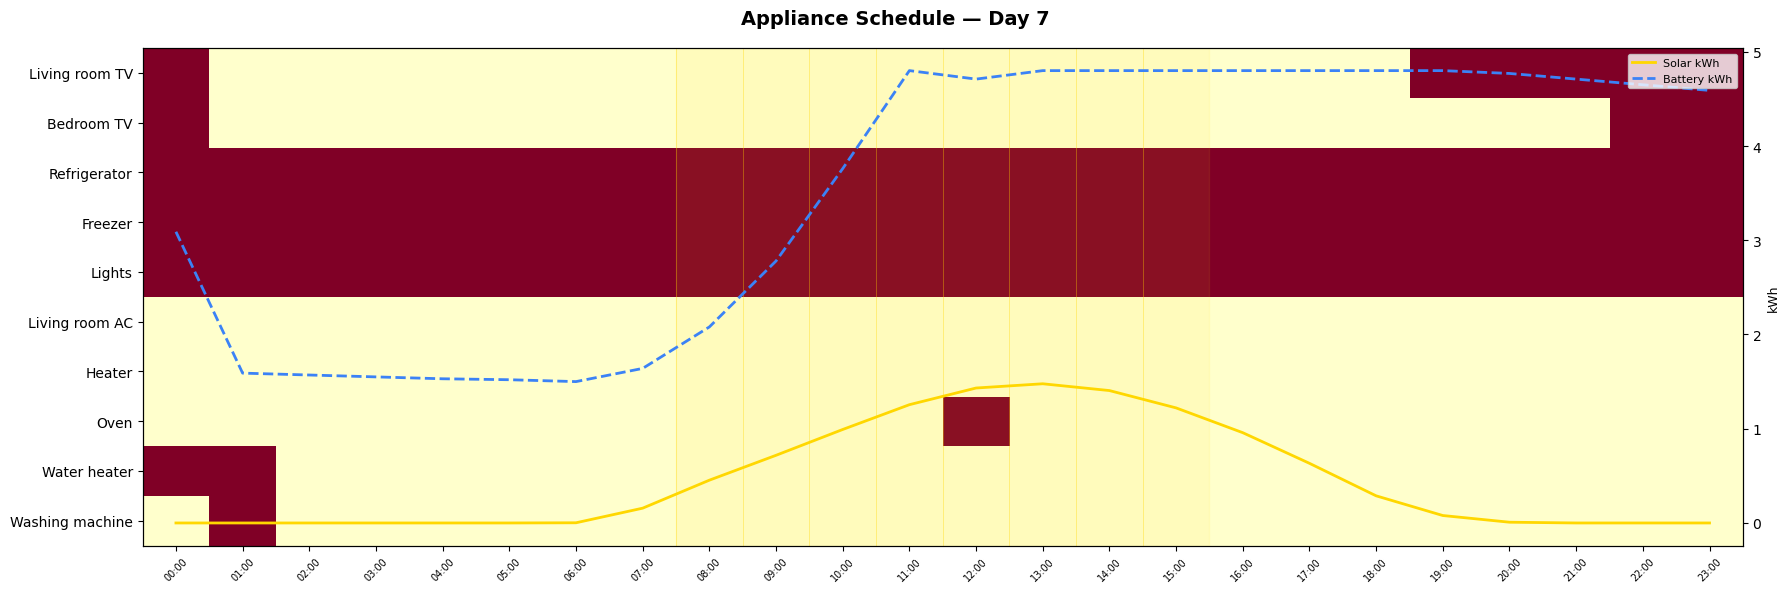

Saved day_7_schedule.png


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

schedule = pd.read_csv("weekly_schedule.csv")

# Get all On/Off columns dynamically from the schedule
# Skip non-appliance columns
SKIP_COLS = ["day", "hour", "solar_kwh", "battery_kwh", "battery_state", "total_load_kwh"]
APPLIANCES = [col for col in schedule.columns if col not in SKIP_COLS]

x_labels = [f"{h:02d}:00" for h in range(24)]

for day in range(1, 8):
    day_df = schedule[schedule["day"] == day].reset_index(drop=True)

    # Build binary matrix
    matrix = np.array([[1 if str(day_df[col].iloc[h]) == "On" else 0
                        for h in range(len(day_df))]
                       for col in APPLIANCES])

    fig, ax = plt.subplots(figsize=(18, 6))
    fig.suptitle(f"Appliance Schedule — Day {day}", fontsize=14, fontweight="bold")

    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

    ax.set_yticks(range(len(APPLIANCES)))
    ax.set_yticklabels(APPLIANCES, fontsize=10)
    ax.set_xticks(range(len(day_df)))
    ax.set_xticklabels(x_labels, fontsize=7, rotation=45)

    # Solar peak band
    for h in range(8, 16):
        ax.axvline(h - 0.5, color="gold", linewidth=0.5, alpha=0.5)
    ax.axvspan(7.5, 15.5, alpha=0.08, color="gold", label="Solar peak")

    # Solar and battery overlay
    ax2 = ax.twinx()
    ax2.plot(range(len(day_df)), day_df["solar_kwh"].values,
             color="gold", linewidth=2, label="Solar kWh")
    ax2.plot(range(len(day_df)), day_df["battery_kwh"].values,
             color="#3b82f6", linewidth=2, linestyle="--", label="Battery kWh")
    ax2.set_ylabel("kWh", fontsize=9)
    ax2.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.savefig(f"day_{day}_schedule.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved day_{day}_schedule.png")